# Coordinates in Space and Time

*Ben Jacobson-Bell, Ay121, last updated Feb 20 2026*

This notebook demonstrates some of the functionality of the `ugradio.coord` library to help you plan your observations and write your analyses most effectively. 

For instance, suppose you want to look at hydrogen in the Galactic plane and want to know where to point the horn antenna. You know the Galactic plane has a Galactic latitude ($b$) of 0, and you can pick essentially any Galactic longitude you like, but Galactic coordinates aren't so useful for pointing a telescope. You really want the altitude and azimuth from New Campbell Hall (NCH).

This notebook will help you answer that question and provide some other potentially useful notes about time and space in `astropy` and `ugradio`.

**Note:** This notebook requires `ugradio`. You can run the notebook on the `ugastro` computer if you like, where `ugradio` is already installed --- you can run Jupyter notebooks on remote computers using a variety of tools, including VSCode. You can also install `ugradio` on your own computer. Talk to me if you'd like help troubleshooting either of these options.

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
import ugradio
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy import units as u

Let's start, briefly, with time. The `astropy.time` library is great for this, and some functionality is wrapped in `ugradio.timing`.

In [ ]:
# Get the current time in UTC using your computer's clock

t = Time.now()
print('Current time:')
print(t)
print('Current time in JD:')
print(t.jd)

Current time:
2026-02-21 00:04:18.379748
Current time in JD:
2461092.502990506


Remember `astropy.time` doesn't know your time zone unless you tell it, so by default time will be given in UTC.

UTC is 8 hours ahead of Pacific Time until March 8 this year, when it will become 7 hours ahead.

In [3]:
# Suppose you have an observation scheduled for February 28 at 3pm. What JD is this?

t = Time('2026-02-28T23:00:00', format='isot', scale='utc')
print(t.jd)

2461100.4583333335


Now let's get into sky coordinate systems (e.g. equatorial, alt-az, galactic, etc.). What do you want to see, and what does this mean for where you should point your telescope?

Let's use the Pleiades star cluster as an example. Looking up "Pleiades" on Stellarium or similar software can tell you its right ascension and declination. In the below cell, let's put these into the variables `ra` and `dec`.

In [5]:
# Pleiades / M45
ra = '03 48 33.9' # hh mm ss
dec = '24 11 56.3' # dd mm ss
c = SkyCoord(ra, dec, unit=(u.hourangle, u.deg)) # need to specify units

# Convert RA and DEC to degrees

ra = c.ra.degree
dec = c.dec.degree
print(ra, dec)

57.14124999999999 24.198972222222224


With RA and DEC in degrees, we can use `ugradio.coord.get_altaz()` to see where we should point our telescope.

Note that by default, this function uses the latitude, longitude, and elevation of Campbell Hall, stored in `ugradio.nch`. For Lab 4, when we use Leuschner, you'll need to change these values, but they're okay to use for now.

In [6]:
alt, az = ugradio.coord.get_altaz(ra, dec)
# by default, get the alt and az right now at Campbell Hall
print(az, alt) # in degrees

115.01008793340054 64.57734287083886


## A note on coordinate systems over time

`SkyCoord` will also let you pull RA and DEC directly from catalogs for most objects. Let's compare the RA/DEC in Stellarium to the `SkyCoord` lookup.

In [ ]:
# cn = 'coordinate from name'
cn = SkyCoord.from_name('M45') # M45 = Pleiades
print(c.ra.degree, c.dec.degree)
print(cn.ra.degree, cn.dec.degree)

57.14124999999999 24.198972222222224
56.65833333 24.17805556


They differ by about half a degree in RA!

This is mainly because of the precession of Earth's axis, which modifies the equatorial (RA/DEC) coordinate system over time.

By default, `SkyCoord.from_name()` will pull object coordinates using the J2000 epoch (now ~26 years out of date). Let's use the `ugradio.coord.precess()` function to update the looked-up coordinates to our current epoch.

In [11]:
ra = cn.ra.degree
dec = cn.dec.degree

ranow, decnow = ugradio.coord.precess(ra, dec)
print(ra, dec)
print(ranow, decnow)

56.65833333 24.17805556
57.04797263717995 24.2575993858001


They still differ by a little bit. I believe this is due to proper motion, which Stellarium takes into account but `ugradio.coord.precess()` does not. It's mainly just a noticeable effect for nearby stars and star clusters like the Pleiades, so it shouldn't affect your work for this class at all.

## Galactic coordinates

In class, Aaron wrote down a matrix that converts equatorial Cartesian vectors to Galactic Cartesian vectors. The matrix looks like this:
$$
\begin{bmatrix}
-0.05 & -0.87 & -0.48 \\
0.49 & -0.44 & 0.75 \\
-0.87 & -0.20 & 0.46 \\
\end{bmatrix}
$$
We can use `astropy` to derive this to greater precision. First, we need a way to go from latitude and longitude (two angles) to Cartesian vectors.

In [9]:
def x(long, lat):
    return np.cos(lat)*np.cos(long)
def y(long, lat):
    return np.cos(lat)*np.sin(long)
def z(long, lat):
    return np.sin(lat)

We want the unit vectors: $s_1 = [1,0,0]$, $s_2 = [0,1,0]$, $s_3 = [0,0,1]$.

Consider for yourself the latitudes and longitudes needed to form these vectors using the above functions. The answers are in the next cell.

In [10]:
# s1 = [1,0,0]: lat = 0, long = 0
# s2 = [0,1,0]: lat = 0, long = np.pi/2
# s3 = [0,0,1]: lat = np.pi/2, long = 0

c1 = SkyCoord(0,0, unit=(u.radian, u.radian))
c2 = SkyCoord(np.pi/2,0, unit=(u.radian, u.radian))
c3 = SkyCoord(0,np.pi/2, unit=(u.radian, u.radian))
# transform from equatorial to galactic using astropy
cg1 = c1.transform_to('galactic')
cg2 = c2.transform_to('galactic')
cg3 = c3.transform_to('galactic')
l1, b1 = cg1.l.radian, cg1.b.radian
l2, b2 = cg2.l.radian, cg2.b.radian
l3, b3 = cg3.l.radian, cg3.b.radian

print(x(l1, b1), x(l2, b2), x(l3, b3))
print(y(l1, b1), y(l2, b2), y(l3, b3))
print(z(l1, b1), z(l2, b2), z(l3, b3))

-0.05487565771259179 -0.873437051955616 -0.4838350736167154
0.4941094371927275 -0.44482972122329556 0.7469821839866676
-0.8676661375596587 -0.19807633727300075 0.4559838136873016


There's the matrix, now to much higher precision!

## Plotting in Galactic coordinates

The last cell demonstrates some of the utility of plotting sky positions in different coordinate systems.

It pulls sky coordinates for several open clusters and globular clusters from the Messier catalog. Then it plots them in RA/DEC and in Galactic coordinates.

Note that open clusters tend to be concentrated within the Galactic plane, while globulars can appear anywhere!

M6
M7
M11
M16
M18
M21
M23
M24
M25
M26
M29
M34
M35
M36
M37
M38
M39
M41
M44
M45
M46
M47
M48
M50
M52
M67
M73
M93
M103
M75
M2
M80
M54
M15
M28
M62
M92
M5
M13
M30
M53
M69
M70
M79
M3
M10
M22
M9
M14
M19
M4
M12
M72
M56
M68
M107
M71
M55


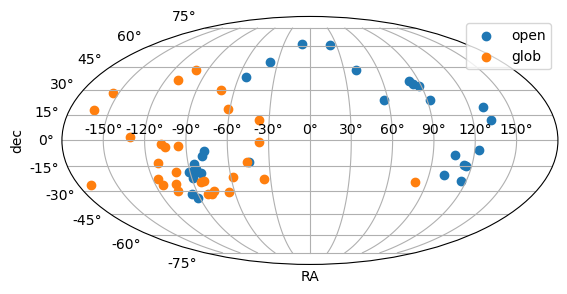

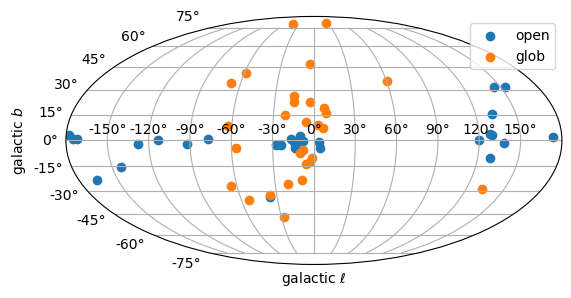

In [18]:
list_open = ['M6', 'M7', 'M11', 'M16', 'M18', 'M21', 'M23', 'M24', 'M25', 'M26', 'M29', 'M34', 'M35', 'M36', 'M37', 'M38',
             'M39', 'M41', 'M44', 'M45', 'M46', 'M47', 'M48', 'M50', 'M52', 'M67', 'M73', 'M93', 'M103']
list_glob = ['M75', 'M2', 'M80', 'M54', 'M15', 'M28', 'M62', 'M92', 'M5', 'M13', 'M30', 'M53', 'M69', 'M70', 'M79',
             'M3', 'M10', 'M22', 'M9', 'M14', 'M19', 'M4', 'M12', 'M72', 'M56', 'M68', 'M107', 'M71', 'M55']

open_ra = []
open_dec = []
open_l = []
open_b = []
glob_ra = []
glob_dec = []
glob_l = []
glob_b = []

for obj in list_open:
    c = SkyCoord.from_name(obj)
    cg = c.transform_to('galactic')
    open_ra.append(c.ra.wrap_at('180d').radian)
    open_dec.append(c.dec.radian)
    open_l.append(-cg.l.wrap_at('180d').radian)
    open_b.append(cg.b.radian)
    print(obj)
for obj in list_glob:
    c = SkyCoord.from_name(obj)
    cg = c.transform_to('galactic')
    glob_ra.append(c.ra.wrap_at('180d').radian)
    glob_dec.append(c.dec.radian)
    glob_l.append(-cg.l.wrap_at('180d').radian)
    glob_b.append(cg.b.radian)
    print(obj)

plt.subplot(projection='mollweide')
plt.scatter(open_ra, open_dec, label='open')
plt.scatter(glob_ra, glob_dec, label='glob')
plt.xlabel('RA')
plt.ylabel('dec')
plt.grid()
plt.legend()
plt.show()

plt.subplot(projection='mollweide')
plt.scatter(open_l, open_b, label='open')
plt.scatter(glob_l, glob_b, label='glob')
plt.xlabel('galactic $\ell$')
plt.ylabel('galactic $b$')
plt.grid()
plt.legend()
plt.show()